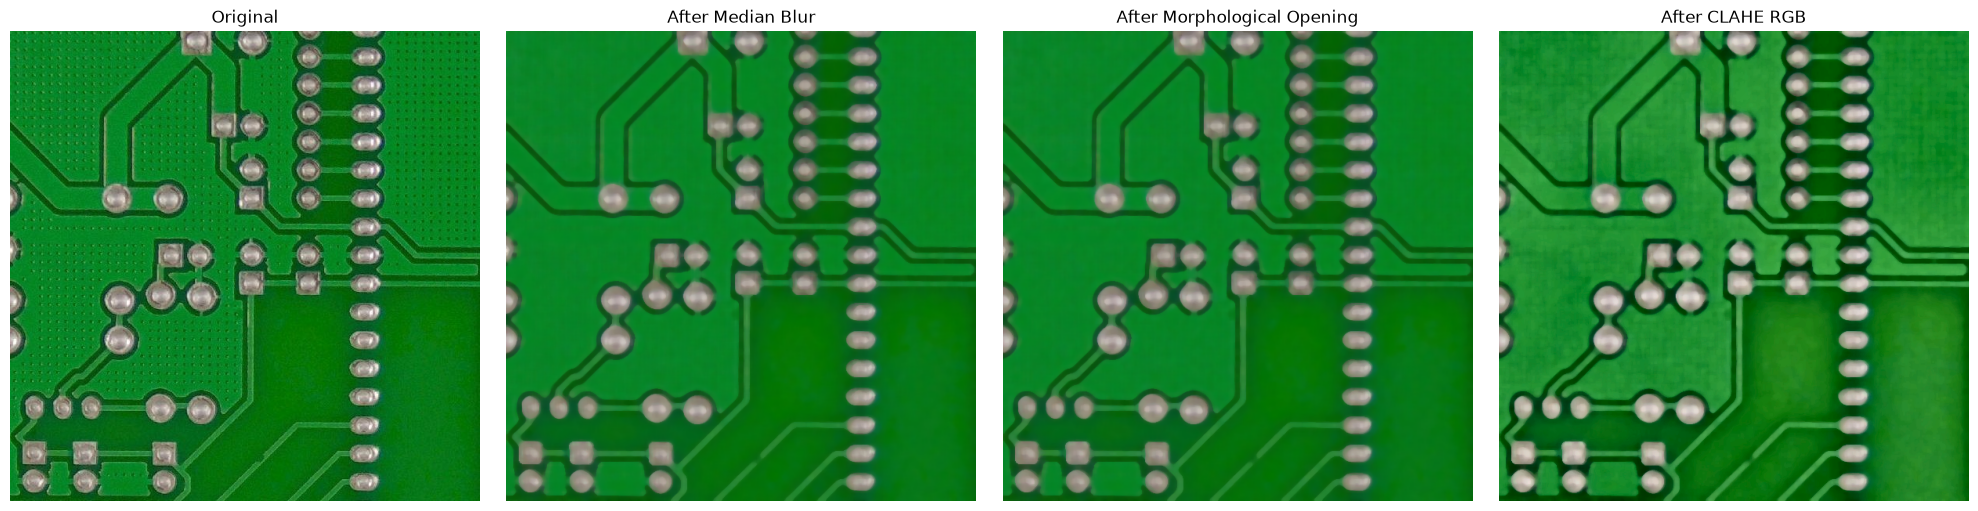

In [4]:
from pathlib import Path
import os

import cv2
import matplotlib.pyplot as plt

from function.preprocessing_function import (
    clahe_rgb,
    median_filter,
    morphological_opening,
)
from pidinet.custom_pidinet_main import pidinet_main


# Change this path to preview another image.
image_path = Path(
    r"C:\Y3S1\image_processing\assignment\pcb-defect-dataset\test\images\l_light_01_mouse_bite_02_2_600.jpg"
)

project_root = image_path.parents[3]
os.chdir(project_root)

demo_input_dir = project_root / "demo_preprocessed" / "test" / "images"
demo_input_dir.mkdir(parents=True, exist_ok=True)

image_bgr = cv2.imread(str(image_path))
if image_bgr is None:
    raise FileNotFoundError(f"Cannot load image: {image_path}")

median_image_bgr = median_filter(image_bgr)
opened_image_bgr = morphological_opening(median_image_bgr)

# clahe_rgb expects an RGB image, while cv2.imread returns BGR.
opened_image_rgb = cv2.cvtColor(opened_image_bgr, cv2.COLOR_BGR2RGB)
clahe_image_rgb = clahe_rgb(opened_image_rgb)

images = [
    cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(median_image_bgr, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(opened_image_bgr, cv2.COLOR_BGR2RGB),
    clahe_image_rgb,
]
titles = [
    "Original",
    "After Median Blur",
    "After Morphological Opening",
    "After CLAHE RGB",
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for axis, image, title in zip(axes, images, titles):
    axis.imshow(image)
    axis.set_title(title)
    axis.axis("off")

fig.tight_layout()
plt.show()

preprocessed_bgr = cv2.cvtColor(clahe_image_rgb, cv2.COLOR_RGB2BGR)
preprocessed_path = demo_input_dir / "demo.png"
if not cv2.imwrite(str(preprocessed_path), preprocessed_bgr):
    raise OSError(f"Cannot save preprocessed image: {preprocessed_path}")


Running PIDinet for test images...
DATASET: ./demo_preprocessed/test/images
Namespace(savedir='./KHS/pidinet/results', datadir='./demo_preprocessed/test/images', custom_img_dir='./edge_detection/demo/test/output_imgs', custom_mat_dir='./edge_detection/demo/test/output_mats', only_bsds=False, ablation=False, dataset=['Custom'], model='pidinet_converted', sa=True, dil=True, config='carv4', seed=1787871440, gpu='0', checkinfo=False, epochs=20, iter_size=24, lr=0.005, lr_type='multistep', lr_steps=None, opt='adam', wd=0.0001, workers=0, eta=0.3, lmbda=1.1, resume=False, print_freq=10, save_freq=1, evaluate='./KHS/pidinet/trained_models/table7_pidinet.pth', evaluate_converted=True, use_cuda=True)
{'layer0': 'cd', 'layer1': 'ad', 'layer2': 'rd', 'layer3': 'cv', 'layer4': 'cd', 'layer5': 'ad', 'layer6': 'rd', 'layer7': 'cv', 'layer8': 'cd', 'layer9': 'ad', 'layer10': 'rd', 'layer11': 'cv', 'layer12': 'cd', 'layer13': 'ad', 'layer14': 'rd', 'layer15': 'cv'}
initialization done
conv weights: lr

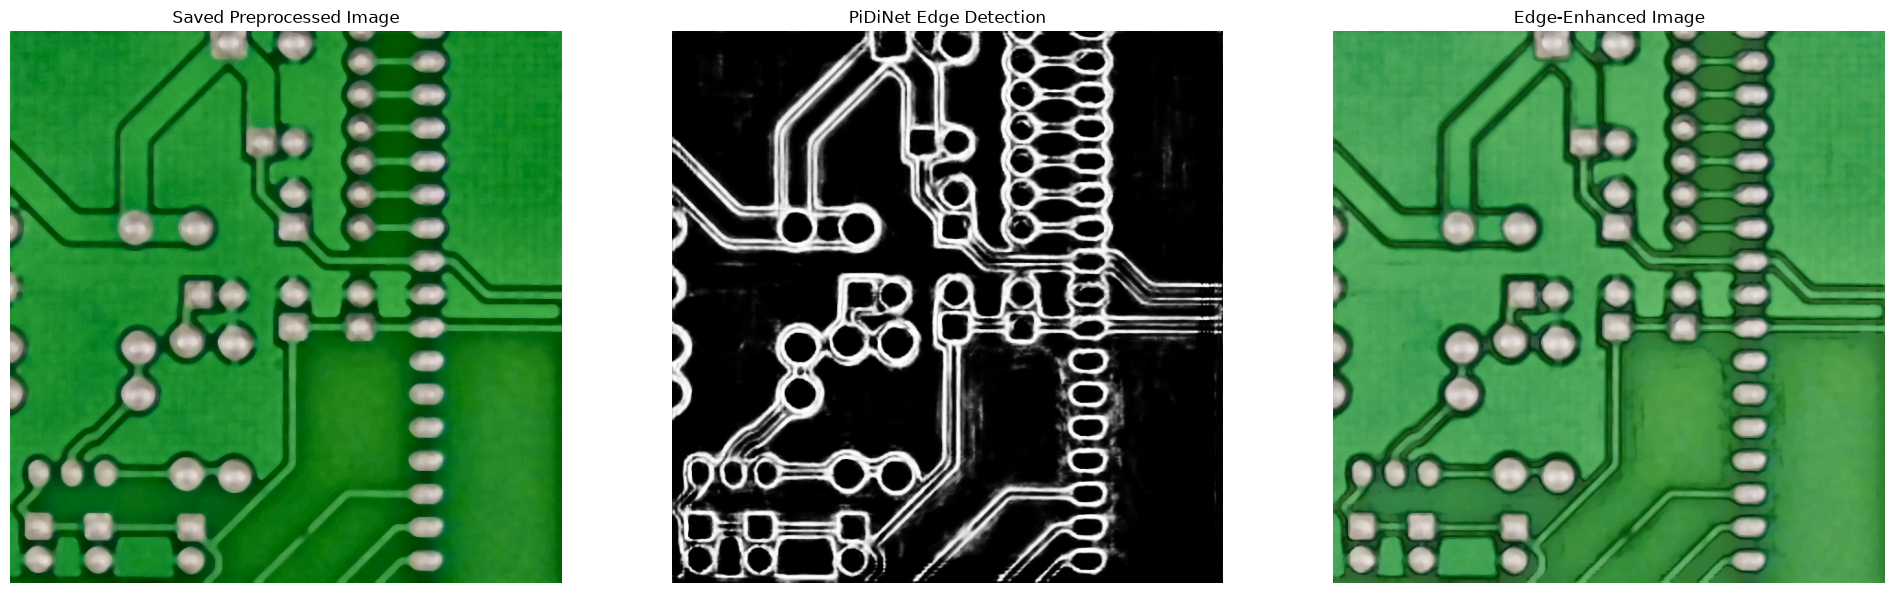

Preprocessed image saved to: C:\Y3S1\image_processing\assignment\demo_preprocessed\test\images\demo.png
Edge detection output saved to: C:\Y3S1\image_processing\assignment\edge_detection\demo\test\output_imgs\demo.png
Edge-enhanced image saved to: C:\Y3S1\image_processing\assignment\edge_detection\demo\test\enhanced\demo_enhanced.png


In [5]:
# Run PiDiNet on the saved preprocessed image.
pidinet_main(
    type_of_image="test",
    dataset_source="demo_preprocessed",
    new_dataset_name="demo",
)

edge_output_dir = project_root / "edge_detection" / "demo" / "test"
edge_output_path = edge_output_dir / "output_imgs" / "demo.png"
edge_mat_path = edge_output_dir / "output_mats" / "demo.mat"
edge_image = cv2.imread(str(edge_output_path), cv2.IMREAD_GRAYSCALE)
if edge_image is None:
    raise FileNotFoundError(f"Cannot load edge output: {edge_output_path}")

# Use marge_pidinet.py to merge the saved image with the PiDiNet edge map.
from KHS import marge_pidinet

enhanced_dir = project_root / "edge_detection" / "demo" / "test" / "enhanced"
enhanced_dir.mkdir(parents=True, exist_ok=True)
enhanced_path = enhanced_dir / "demo_enhanced.png"
marge_pidinet.enhance_image(
    image_path=preprocessed_path,
    mat_path=edge_mat_path,
    output_path=enhanced_path,
    threshold=0.3,
    original_weight=0.8,
    edge_weight=0.2,
)

enhanced_image_bgr = cv2.imread(str(enhanced_path))
if enhanced_image_bgr is None:
    raise FileNotFoundError(f"Cannot load enhanced output: {enhanced_path}")
enhanced_image = cv2.cvtColor(enhanced_image_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes[0].imshow(clahe_image_rgb)
axes[0].set_title("Saved Preprocessed Image")
axes[0].axis("off")

axes[1].imshow(edge_image, cmap="gray")
axes[1].set_title("PiDiNet Edge Detection")
axes[1].axis("off")

axes[2].imshow(enhanced_image)
axes[2].set_title("Edge-Enhanced Image")
axes[2].axis("off")

fig.tight_layout()
plt.show()

print(f"Preprocessed image saved to: {preprocessed_path}")
print(f"Edge detection output saved to: {edge_output_path}")
print(f"Edge-enhanced image saved to: {enhanced_path}")


Ultralytics 8.4.127  Python-3.14.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.20.1 ms, read: 184.552.0 MB/s, size: 330.6 KB)
val: Scanning C:\Y3S1\image_processing\assignment\pcb-defect-median-opened-claheRGB-edgeEnhanced(ID1)\test\labels.cache... 1068 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1068/1068 165.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 67/67 1.7it/s 40.2s0.5ss
                   all       1068       2158      0.982      0.977       0.99      0.608
            mouse_bite        168        332      0.981      0.982      0.992      0.601
                  spur        169        348      0.988      0.978      0.991      0.587
          missing_hole        190        379      0.982      0.994      0.994      0.649
                 short        18

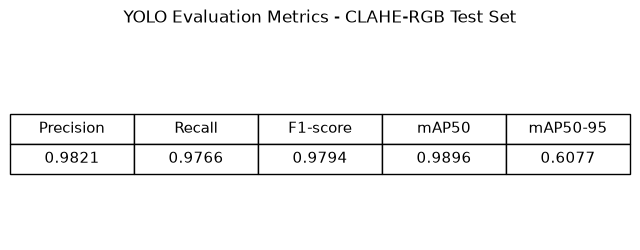

Model: C:\Y3S1\image_processing\assignment\runs\detect\runs\pcb_defect_median-opened-claheRGB-edgeEnhanced(ID1)\weights\best.pt
Dataset: C:\Y3S1\image_processing\assignment\pcb-defect-median-opened-claheRGB-edgeEnhanced(ID1)\data.yaml
Evaluation results saved to: C:\Y3S1\image_processing\assignment\demo_preprocessed\runs\demo_yolo_evaluation\claheRGB


In [49]:
from ultralytics import YOLO


# Evaluate the trained YOLO detector on the CLAHE-RGB test set.
yolo_model_path = project_root / "runs" / "detect" / "runs" / "pcb_defect_median-opened-claheRGB-edgeEnhanced(ID1)" / "weights" / "best.pt"
yolo_data_path = project_root / "pcb-defect-median-opened-claheRGB-edgeEnhanced(ID1)" / "data.yaml"

yolo_model = YOLO(str(yolo_model_path))
yolo_metrics = yolo_model.val(
    data=str(yolo_data_path),
    split="test",
    project=str(project_root / "runs" / "demo_yolo_evaluation"),
    name="claheRGB",
    exist_ok=True,
    plots=True,
)

precision = float(yolo_metrics.box.mp)
recall = float(yolo_metrics.box.mr)
map50 = float(yolo_metrics.box.map50)
map50_95 = float(yolo_metrics.box.map)
f1_score = (
    2 * precision * recall / (precision + recall)
    if precision + recall > 0
    else 0.0
)

metric_names = ["Precision", "Recall", "F1-score", "mAP50", "mAP50-95"]
metric_values = [precision, recall, f1_score, map50, map50_95]

fig, axis = plt.subplots(figsize=(8, 2.5))
axis.axis("off")
metric_table = axis.table(
    cellText=[[f"{value:.4f}" for value in metric_values]],
    colLabels=metric_names,
    cellLoc="center",
    loc="center",
)
metric_table.auto_set_font_size(False)
metric_table.set_fontsize(11)
metric_table.scale(1, 1.8)
axis.set_title("YOLO Evaluation Metrics - CLAHE-RGB Test Set", pad=18)
plt.show()

print(f"Model: {yolo_model_path}")
print(f"Dataset: {yolo_data_path}")
print(f"Evaluation results saved to: {project_root / 'demo_preprocessed' /'runs' / 'demo_yolo_evaluation' / 'claheRGB'}")
